##  Model Analysis

### 1 Model profiling and benchmark

Ref: How to Scale Your Model  A Systems View of LLMs on TPUs by Google

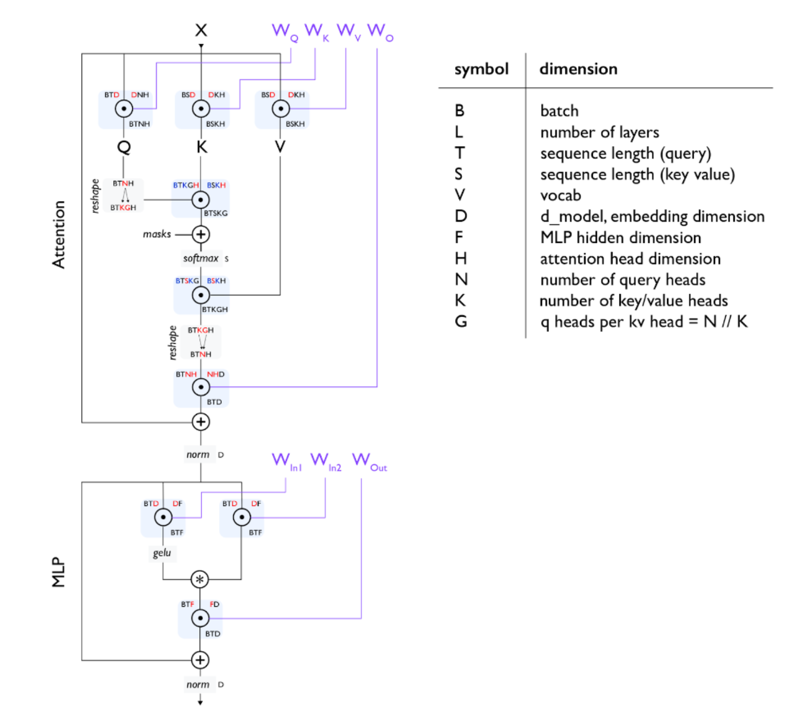

In [1]:
import sys
if "code" not in sys.path: sys.path.insert(0, "code")   # model modules live in code/
from helper import plot

plot("img/LLM_tuning.png", 800)

### 2 Hyper parameters

In [2]:

B = 16 # Batch size
L = 32 # Layers
T = 2048 # Q length
S = 2048 # K length
D = 4096 # dimension
F = 14336 # FFN inter dim
N = 32 # Q head
K = 8 # KV head
H = 128 # d_head
G = N / K # Q heads / KV head
d_kv = 1024 # d_kv

Quant_weight = 1 # Weight quantization with 8 bit
Quant_act = 2 # Activation quantization with 16 bit

### 3 Prefill intensity

In [3]:
X = B * T * D
assert X == 16 * 2048 * 4096

W_Q = D * N * H
assert W_Q == 4096 * 32 * 128

W_K = D * K * H
W_V = D * K * H
assert W_K == 4096 * 8 * 128

W_O = N * H * D
assert W_O == 32 * 128 * 4096

W_in1 = D * F
W_in2 = D * F
W_out = F * D

flops = 0
byts_transferred = 0
############################# ATTENTION
# 0 Pre RMSNorm (4D + 2)
flops += B * T * (4 * D + 2)
# write normalized input.
byts_transferred += Quant_act * (2 * X + D)

# 1 Read Q K V weights
byts_transferred += Quant_weight * (W_Q + W_K + W_V)

# 2 Compute Q K V
flops += 2 * B * T * W_Q
flops += 2 * B * S * (W_K + W_V)
# Read X_tile
byts_transferred += Quant_act * (B * T * D + 2 * B * S * D)
# Write Q (K V)
byts_transferred += Quant_act * (B * T * N * H + 2 * B * S * K * H)
# RoPE Q K
flops += 3 * (B * T * N * H + B * S * K * H)
# Write QK back to HBM
byts_transferred += 2 * Quant_act * (B * T * N * H + B * S * K * H)

# Read shared sin/cos tables once for this operation.
# T positions × H/2 pairs × 2 tables.
byts_transferred += Quant_act * T * H

# 3 Compute P = Q @ K.T.
flops += 2 * B * S * T * D

# Read Q and K; write S
byts_transferred += Quant_act * (
    B * T * N * H
    + B * S * K * H
    + B * N * T * S
)

# Scale scores by 1/sqrt(H) and add causal mask.
# Fusioned: one multiplication + one mask addition per score.
flops += 2 * B * N * T * S

# Read and write S
byts_transferred += 2 * Quant_act * B * N * T * S

# 3b Stable softmax over S.
# Per row:
# subtract maximum: S operations
# exp:              S operations
# sum:              S - 1 operations
# divide:           S operations
# Maximum comparisons are excluded.
flops += B * N * T * (4 * S - 1)

# Read scores; write probabilities.
byts_transferred += 2 * Quant_act * B * N * T * S

# 4 Compute O = softmax(P) @ V
flops += 2 * B * S * T * D

# Read probabilities and V; write O.
byts_transferred += Quant_act * (B * N * T * S + B * S * K * H + B * T * N * H)

# 5 Read output-projection weights and compute O @ W_O.
byts_transferred += Quant_weight * W_O
flops += 2 * B * T * W_O

# Read O; write projected output.
byts_transferred += Quant_act * (
    B * T * N * H + X
)

# 6 Attention residual addition.
flops += X

# Read residual and projected output; write sum.
byts_transferred += Quant_act * 3 * X

attention_flops = flops
attention_bytes = byts_transferred



#############################  MLP #############################

# 1 Pre-MLP RMSNorm.
flops += 4 * X + 2 * B * T
byts_transferred += Quant_act * (2 * X + D)

# 2 MLP gate and up projections.
byts_transferred += Quant_weight * (W_in1 + W_in2)
flops += 2 * B * T * (W_in1 + W_in2)

# Two separate input reads and two intermediate writes.
byts_transferred += Quant_act * (
    2 * X + 2 * B * T * F
)

# 3 SiLU on gate projection: x / (1 + exp(-x)).
# Negation, exp, addition and division.
flops += 4 * B * T * F
# Read gate projection; write SiLU result.
byts_transferred += Quant_act * 2 * B * T * F

# 4 Elementwise multiply: SiLU(gate) * up.
flops += B * T * F
# Read both operands; write product.
byts_transferred += Quant_act * 3 * B * T * F

# 5 MLP down projection.
byts_transferred += Quant_weight * W_out
flops += 2 * B * T * W_out
# Read intermediate; write down-projection output.
byts_transferred += Quant_act * (B * T * F + X)

# 6 MLP residual addition.
flops += X
byts_transferred += Quant_act * 3 * X

mlp_flops = flops - attention_flops
mlp_bytes = byts_transferred - attention_bytes

intensity = flops / byts_transferred

print("Per transformer layer:")
print(f"Attention + norm/residual FLOPs: {attention_flops:,}")
print(f"Attention + norm/residual bytes: {attention_bytes:,}")
print(f"MLP + norm/residual FLOPs: {mlp_flops:,}")
print(f"MLP + norm/residual bytes: {mlp_bytes:,}")
print(f"Total FLOPs: {flops:,}")
print(f"Total bytes transferred: {byts_transferred:,}")
print(f"Intensity: {intensity:,.2f} FLOPs/byte")

print(f"\nAcross {L} transformer layers:")
print(f"Total FLOPs: {L * flops:,}")
print(f"Total bytes transferred: {L * byts_transferred:,}")
print(f"Total bits transferred: {8 * L * byts_transferred:,}")


Per transformer layer:
Attention + norm/residual FLOPs: 3,862,349,021,184
Attention + norm/residual bytes: 30,241,464,320
MLP + norm/residual FLOPs: 11,547,892,056,064
MLP + norm/residual bytes: 9,839,845,376
Total FLOPs: 15,410,241,077,248
Total bytes transferred: 40,081,309,696
Intensity: 384.47 FLOPs/byte

Across 32 transformer layers:
Total FLOPs: 493,127,714,471,936
Total bytes transferred: 1,282,601,910,272
Total bits transferred: 10,260,815,282,176


### 4 Decode intensity Analysis

In [4]:
# Existing model parameters:
# B, L, D, F, N, K, H
# Quant_weight = 1 byte
# Quant_act = 2 bytes
# RMSNorm weights remain 16-bit.

input_tokens = 2048
output_tokens = 256
T = 1

# Prefill produces the first output token.
decode_steps = output_tokens - 1

X = B * T * D

W_Q = D * N * H
W_K = D * K * H
W_V = D * K * H
W_O = N * H * D

W_in1 = D * F
W_in2 = D * F
W_out = F * D

total_flops = 0
total_byts_transferred = 0

attention_total_flops = 0
attention_total_bytes = 0
mlp_total_flops = 0
mlp_total_bytes = 0

for step in range(1, decode_steps + 1):
    # Includes the new token appended during this pass.
    S = input_tokens + step

    flops = 0
    byts_transferred = 0

    # 0 Pre-attention RMSNorm.
    flops += 4 * X + 2 * B * T
    byts_transferred += Quant_act * (2 * X + D)

    # 1 Read Q/K/V projection weights.
    byts_transferred += Quant_weight * (W_Q + W_K + W_V)

    # 2 Compute Q/K/V for ONLY the new token.
    # Use T, not S, for all three projections.
    flops += 2 * B * T * (W_Q + W_K + W_V)

    # Separate projections each read the normalized input.
    byts_transferred += Quant_act * 3 * X

    # Write new Q, unrotated K and V.
    # V is written directly into its KV-cache position.
    byts_transferred += Quant_act * (
        B * T * N * H + 2 * B * T * K * H
    )

    # 2a RoPE on new Q and new K only.
    flops += 3 * (
        B * T * N * H + B * T * K * H
    )

    # Read/write Q and K.
    # Rotated K is written directly into its cache position.
    byts_transferred += 2 * Quant_act * (
        B * T * N * H + B * T * K * H
    )

    # Read sin/cos for the new position, shared across batch/heads.
    byts_transferred += Quant_act * T * H

    # 3 Compute scores against all cached keys.
    flops += 2 * B * T * S * D

    # Read new Q and full K cache; write scores.
    byts_transferred += Quant_act * (
        B * T * N * H
        + B * S * K * H
        + B * N * T * S
    )

    # 3a Scale scores by 1/sqrt(H).
    # No causal-mask operation is needed:
    # the cache contains only past and current positions.
    flops += B * N * T * S
    byts_transferred += 2 * Quant_act * B * N * T * S

    # 3b Stable softmax over S.
    # Maximum comparisons excluded; exp/division count as one each.
    flops += B * N * T * (4 * S - 1)
    byts_transferred += 2 * Quant_act * B * N * T * S

    # 4 Compute O = probabilities @ cached V.
    flops += 2 * B * T * S * D

    # Read probabilities and full V cache; write O.
    byts_transferred += Quant_act * (
        B * N * T * S
        + B * S * K * H
        + B * T * N * H
    )

    # 5 Output projection.
    flops += 2 * B * T * W_O
    byts_transferred += Quant_weight * W_O
    byts_transferred += Quant_act * (
        B * T * N * H + X
    )

    # 6 Attention residual addition.
    flops += X
    byts_transferred += Quant_act * 3 * X

    attention_flops = flops
    attention_bytes = byts_transferred


#############################  MLP #############################

    # 7 Pre-MLP RMSNorm.
    flops += 4 * X + 2 * B * T
    byts_transferred += Quant_act * (2 * X + D)

    # 8 Gate and up projections.
    flops += 2 * B * T * (W_in1 + W_in2)
    byts_transferred += Quant_weight * (W_in1 + W_in2)
    byts_transferred += Quant_act * (
        2 * X + 2 * B * T * F
    )

    # 9 SiLU.
    flops += 4 * B * T * F
    byts_transferred += Quant_act * 2 * B * T * F

    # 10 Elementwise gate multiplication.
    flops += B * T * F
    byts_transferred += Quant_act * 3 * B * T * F

    # 11 Down projection.
    flops += 2 * B * T * W_out
    byts_transferred += Quant_weight * W_out
    byts_transferred += Quant_act * (
        B * T * F + X
    )

    # 12 MLP residual addition.
    flops += X
    byts_transferred += Quant_act * 3 * X

    mlp_flops = flops - attention_flops
    mlp_bytes = byts_transferred - attention_bytes

    # Accumulate across all transformer layers.
    total_flops += L * flops
    total_byts_transferred += L * byts_transferred

    attention_total_flops += L * attention_flops
    attention_total_bytes += L * attention_bytes
    mlp_total_flops += L * mlp_flops
    mlp_total_bytes += L * mlp_bytes

    if step == 1 or step == decode_steps:
        print(f"\nDecode pass {step}, KV length S = {S}:")
        print(f"FLOPs per layer: {flops:,}")
        print(f"Bytes per layer: {byts_transferred:,}")
        print(f"Intensity: {flops / byts_transferred:,.2f} FLOPs/byte")

# Aggregate intensity is total FLOPs / total bytes.
intensity = total_flops / total_byts_transferred

print(f"\nAll {decode_steps} decode passes, all {L} layers:")
print(f"Total FLOPs: {total_flops:,}")
print(f"Total bytes transferred: {total_byts_transferred:,}")
print(f"Total bits transferred: {8 * total_byts_transferred:,}")
print(f"Attention intensity: "
      f"{attention_total_flops / attention_total_bytes:,.2f} FLOPs/byte")
print(f"MLP intensity: "
      f"{mlp_total_flops / mlp_total_bytes:,.2f} FLOPs/byte")
print(f"Combined intensity: {intensity:,.2f} FLOPs/byte")


Decode pass 1, KV length S = 2049:
FLOPs per layer: 7,523,747,904
Bytes per layer: 371,808,512
Intensity: 20.24 FLOPs/byte

Decode pass 255, KV length S = 2303:
FLOPs per layer: 7,590,982,720
Bytes per layer: 390,015,232
Intensity: 19.46 FLOPs/byte

All 255 decode passes, all 32 layers:
Total FLOPs: 61,668,100,945,920
Total bytes transferred: 3,108,240,875,520
Total bits transferred: 24,865,927,004,160
Attention intensity: 9.59 FLOPs/byte
MLP intensity: 31.17 FLOPs/byte
Combined intensity: 19.84 FLOPs/byte


### 5. Conclusion

1. **Prefill Intensity: 384.47 FLOPs/byte:**

Total FLOPs: 493,127,714,471,936

Total bytes transferred: 1,282,601,910,272

2. **Decode Intensity: 19.46 FLOPs/byte**

Total FLOPs: 61,668,100,945,920

Total bytes transferred: 3,108,240,875,520

Total bits transferred: 24,865,927,004,160

Roofline:

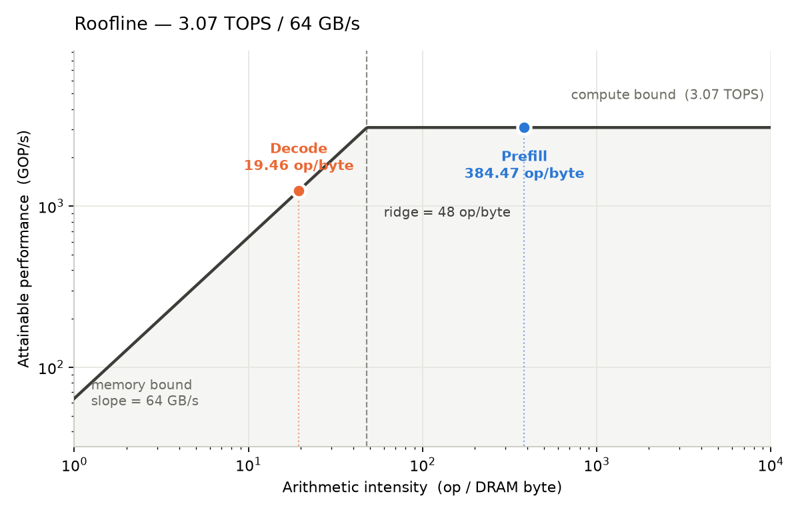

In [5]:
plot(f"img/roofline.png", 800)